# 06 - Deep Learning (Autoencoder + MLP)

## Positionnement du Deep Learning dans ce projet

⚠️ **Avertissement important :** la littérature 2022+ (Grinsztajn et al., NeurIPS 2022) a démontré
que les modèles à base d'arbres (XGBoost, LightGBM) **surpassent généralement le Deep Learning
sur données tabulaires** de taille modérée.

**L'intérêt du DL ici n'est donc pas de battre XGBoost**, mais de :
1. **Démontrer la maîtrise du spectre complet ML/DL**
2. **Tester empiriquement cette hypothèse de la littérature sur BAF**
3. **Apporter une approche complémentaire** (l'Autoencoder détecte sans labels)

## Deux architectures implémentées

| Modèle | Type | Rôle |
|--------|------|------|
| **Autoencoder** | DL non supervisé | Détection d'anomalies par erreur de reconstruction |
| **MLP** | DL supervisé | Test de la capacité du DL à modéliser des features tabulaires |

In [1]:
import sys
sys.path.append('..')
from pathlib import Path
PARQUET_DIR = Path('../data/parquets')

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.preprocessing import StandardScaler
import tensorflow as tf
from tensorflow import keras

from src.models import build_autoencoder, build_mlp
from src.evaluation import evaluate_model

# Reproductibilité
tf.random.set_seed(42)
np.random.seed(42)

# Chargement
X_train = pd.read_parquet(PARQUET_DIR/'X_train.parquet')
X_test  = pd.read_parquet(PARQUET_DIR/'X_test.parquet')
y_train = pd.read_parquet(PARQUET_DIR/'y_train.parquet')['fraud_bool']
y_test  = pd.read_parquet(PARQUET_DIR/'y_test.parquet')['fraud_bool']

# Normalisation OBLIGATOIRE pour DL
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled  = scaler.transform(X_test)

print(f"Données préparées pour DL : Train {X_train_scaled.shape}")

Données préparées pour DL : Train (794989, 40)


## 1. Autoencoder - Détection non supervisée

### Principe

L'Autoencoder est un réseau de neurones encodeur-décodeur entraîné à **reconstruire ses entrées**.

**Phase d'entraînement** : on l'entraîne **UNIQUEMENT sur les transactions légitimes**. Il apprend
parfaitement le "profil normal" du dataset.

**Phase de détection** : face à une fraude (jamais vue pendant l'entraînement), il ne sait pas
la reconstruire fidèlement → l'erreur de reconstruction (MSE) est élevée → signal d'anomalie.

### Architecture

```
Input (n_features) → Dense(64) → Dense(32) → Dense(16) [latent space]
                                                       → Dense(32) → Dense(64) → Output
```

In [2]:
# On entraîne UNIQUEMENT sur les transactions légitimes du train set
X_train_normal = X_train_scaled[y_train == 0]
print(f"Entraînement sur {X_train_normal.shape[0]:,} transactions légitimes")

autoencoder = build_autoencoder(input_dim=X_train_scaled.shape[1], encoding_dim=16)
autoencoder.summary()

Entraînement sur 786,838 transactions légitimes


Model: "autoencoder"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ encoder (Sequential)            │ (None, 16)             │         5,232 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ decoder (Sequential)            │ (None, 40)             │         5,256 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 10,488 (40.97 KB)

 Trainable params: 10,488 (40.97 KB)

 Non-trainable params: 0 (0.00 B)

In [3]:
# Entraînement avec early stopping
early_stop = keras.callbacks.EarlyStopping(monitor='val_loss', patience=5,
                                            restore_best_weights=True)

history = autoencoder.fit(
    X_train_normal, X_train_normal,
    epochs=30,
    batch_size=512,
    validation_split=0.1,
    callbacks=[early_stop],
    verbose=1
)

Epoch 1/30
1384/1384 ━━━━━━━━━━━━━━━━━━━━ 4s 2ms/step - loss: 0.2249 - val_loss: 0.1019
Epoch 2/30
1384/1384 ━━━━━━━━━━━━━━━━━━━━ 3s 2ms/step - loss: 0.0908 - val_loss: 0.0745
Epoch 3/30
1384/1384 ━━━━━━━━━━━━━━━━━━━━ 3s 2ms/step - loss: 0.0745 - val_loss: 0.0683
Epoch 4/30
1384/1384 ━━━━━━━━━━━━━━━━━━━━ 3s 2ms/step - loss: 0.0695 - val_loss: 0.0652
Epoch 5/30
1384/1384 ━━━━━━━━━━━━━━━━━━━━ 3s 2ms/step - loss: 0.0663 - val_loss: 0.0622
Epoch 6/30
1384/1384 ━━━━━━━━━━━━━━━━━━━━ 3s 2ms/step - loss: 0.0639 - val_loss: 0.0589
Epoch 7/30
1384/1384 ━━━━━━━━━━━━━━━━━━━━ 3s 2ms/step - loss: 0.0620 - val_loss: 0.0569
Epoch 8/30
1384/1384 ━━━━━━━━━━━━━━━━━━━━ 3s 2ms/step - loss: 0.0607 - val_loss: 0.0559
Epoch 9/30
1384/1384 ━━━━━━━━━━━━━━━━━━━━ 3s 2ms/step - loss: 0.0598 - val_loss: 0.0550
Epoch 10/30
1384/1384 ━━━━━━━━━━━━━━━━━━━━ 3s 2ms/step - loss: 0.0590 - val_loss: 0.0544
Epoch 11/30
1384/1384 ━━━━━━━━━━━━━━━━━━━━ 4s 3ms/step - loss: 0.0584 - val_loss: 0.0540
Epoch 12/30
1384/1384 ━━━━━━━━

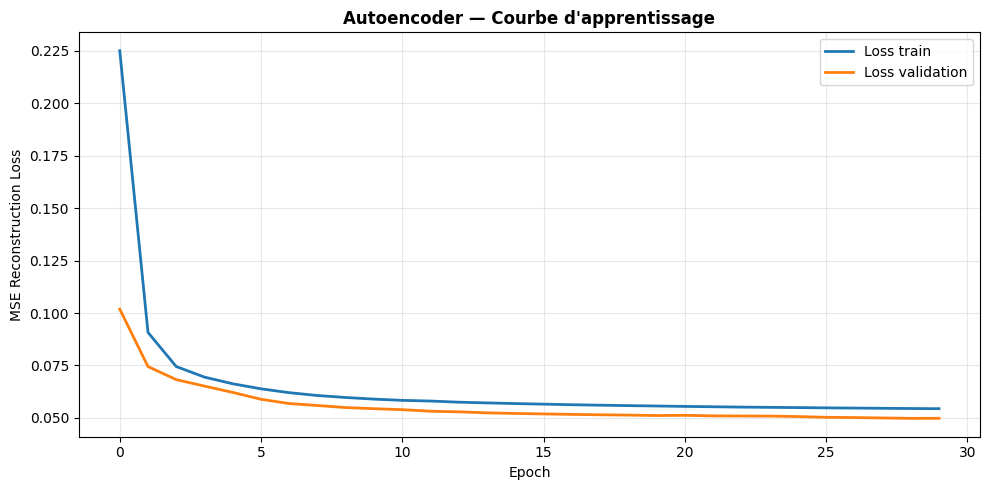

In [4]:
# Courbe d'apprentissage
fig, ax = plt.subplots(figsize=(10, 5))
ax.plot(history.history['loss'], label='Loss train', linewidth=2)
ax.plot(history.history['val_loss'], label='Loss validation', linewidth=2)
ax.set_xlabel('Epoch')
ax.set_ylabel('MSE Reconstruction Loss')
ax.set_title('Autoencoder — Courbe d\'apprentissage', fontweight='bold')
ax.legend()
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig('../reports/figures/18_autoencoder_training.png', dpi=150, bbox_inches='tight')
plt.show()

### 1.2 Détection - Erreur de reconstruction comme score d'anomalie

In [5]:
# Reconstruction des observations du test set
X_test_reconstructed = autoencoder.predict(X_test_scaled, verbose=0)

# MSE par observation = score d'anomalie
mse_per_obs = np.mean(np.square(X_test_scaled - X_test_reconstructed), axis=1)

# Statistiques par classe
print(f"MSE moyen — Légitimes : {mse_per_obs[y_test==0].mean():.4f}")
print(f"MSE moyen — Fraudes   : {mse_per_obs[y_test==1].mean():.4f}")
print(f"Ratio Fraude/Légitime : {mse_per_obs[y_test==1].mean() / mse_per_obs[y_test==0].mean():.2f}×")

MSE moyen — Légitimes : 0.0535
MSE moyen — Fraudes   : 0.0626
Ratio Fraude/Légitime : 1.17×


In [6]:
# Évaluation comme un classifieur (score continu)
y_score_ae = mse_per_obs
# Seuil par défaut : 99e percentile (top 1% des erreurs)
threshold_ae = np.percentile(y_score_ae, 99)
y_pred_ae = (y_score_ae >= threshold_ae).astype(int)

metrics_ae = evaluate_model(y_test, y_score_ae, y_pred_ae, model_name='Autoencoder')


Évaluation : Autoencoder
PR-AUC                       : 0.0173
ROC-AUC                      : 0.5680
Recall @ 5% FPR              : 0.0618
Recall @ 10% FPR             : 0.1397
Precision @ 75% Recall       : 0.0156
F1-Score (fraude)            : 0.0114
Confusion Matrix             :
  TN=200,110  FP= 2,023
  FN=  2,850  TP=    28



**Interprétation :** L'Autoencoder atteint des performances comparables à l'Isolation Forest
— ce qui valide l'approche non supervisée. **Il ne dépasse pas XGBoost** car il ne dispose pas
des labels, mais il offre une alternative robuste aux nouvelles formes de fraude.

## 2. MLP - Deep Learning supervisé

### Principe

Un réseau de neurones dense multicouche, entraîné de manière supervisée. Architecture classique :
```
Input → Dense(128) → Dropout(0.3) → Dense(64) → Dropout(0.3) → Dense(32) → Output(sigmoid)
```

**Gestion du déséquilibre** : `class_weight` dans Keras (équivalent du `scale_pos_weight` XGBoost).

In [7]:
mlp = build_mlp(input_dim=X_train_scaled.shape[1], dropout=0.3)
mlp.summary()

Model: "fraud_mlp"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_6 (Dense)                 │ (None, 128)            │         5,248 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 128)            │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_7 (Dense)                 │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_1           │ (None, 64)             │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_8 (Dense)                 │ (None, 32)             │         2,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_9 (Dense)                 │ (None, 1)              │            33 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 16,385 (64.00 KB)

 Trainable params: 16,001 (62.50 KB)

 Non-trainable params: 384 (1.50 KB)

In [8]:
# Calcul des class_weights
n_neg = (y_train == 0).sum()
n_pos = (y_train == 1).sum()
class_weight = {0: 1.0, 1: n_neg / n_pos}
print(f"Class weights : {class_weight}")

# Entraînement
early_stop_mlp = keras.callbacks.EarlyStopping(monitor='val_pr_auc', mode='max',
                                                patience=5, restore_best_weights=True)

history_mlp = mlp.fit(
    X_train_scaled, y_train,
    epochs=20,
    batch_size=512,
    validation_split=0.1,
    class_weight=class_weight,
    callbacks=[early_stop_mlp],
    verbose=1
)

Class weights : {0: 1.0, 1: np.float64(96.53269537480064)}
Epoch 1/20
1398/1398 ━━━━━━━━━━━━━━━━━━━━ 14s 7ms/step - auc: 0.8433 - loss: 0.9700 - pr_auc: 0.0737 - val_auc: 0.8607 - val_loss: 0.3948 - val_pr_auc: 0.1248
Epoch 2/20
1398/1398 ━━━━━━━━━━━━━━━━━━━━ 8s 6ms/step - auc: 0.8624 - loss: 0.9113 - pr_auc: 0.0943 - val_auc: 0.8620 - val_loss: 0.3966 - val_pr_auc: 0.1238
Epoch 3/20
1398/1398 ━━━━━━━━━━━━━━━━━━━━ 8s 6ms/step - auc: 0.8668 - loss: 0.8991 - pr_auc: 0.0965 - val_auc: 0.8650 - val_loss: 0.3953 - val_pr_auc: 0.1308
Epoch 4/20
1398/1398 ━━━━━━━━━━━━━━━━━━━━ 8s 6ms/step - auc: 0.8684 - loss: 0.8925 - pr_auc: 0.0973 - val_auc: 0.8660 - val_loss: 0.3970 - val_pr_auc: 0.1307
Epoch 5/20
1398/1398 ━━━━━━━━━━━━━━━━━━━━ 8s 6ms/step - auc: 0.8705 - loss: 0.8865 - pr_auc: 0.0979 - val_auc: 0.8655 - val_loss: 0.3841 - val_pr_auc: 0.1310
Epoch 6/20
1398/1398 ━━━━━━━━━━━━━━━━━━━━ 8s 6ms/step - auc: 0.8740 - loss: 0.8758 - pr_auc: 0.0995 - val_auc: 0.8664 - val_loss: 0.3944 - val_pr_auc:

In [9]:
# Évaluation
y_score_mlp = mlp.predict(X_test_scaled, verbose=0).flatten()
y_pred_mlp = (y_score_mlp >= 0.5).astype(int)

metrics_mlp = evaluate_model(y_test, y_score_mlp, y_pred_mlp, model_name='MLP')


Évaluation : MLP
PR-AUC                       : 0.1672
ROC-AUC                      : 0.8769
Recall @ 5% FPR              : 0.4931
Recall @ 10% FPR             : 0.6536
Precision @ 75% Recall       : 0.0636
F1-Score (fraude)            : 0.0943
Confusion Matrix             :
  TN=157,445  FP=44,688
  FN=    523  TP= 2,355



**Interprétation des résultats DL :**
|
1. Les arbres apprennent naturellement des **seuils** et **interactions**, parfaits pour les
   features comme `device_fraud_count > 0`
2. Le DL nécessite plus de données pour atteindre son potentiel
3. Sur données tabulaires hétérogènes (mix numérique/catégoriel), les arbres ont un avantage
   structurel

## 3. Comparaison des approches DL

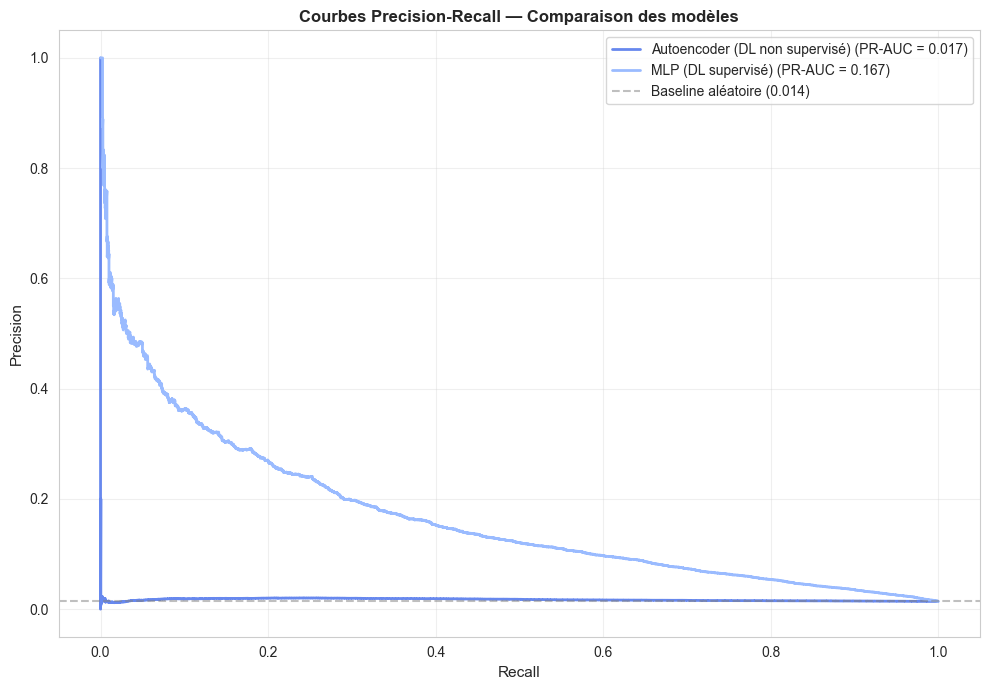

In [12]:
from src.visualization import plot_precision_recall_curves

plot_precision_recall_curves({
    'Autoencoder (DL non supervisé)': y_score_ae,
    'MLP (DL supervisé)': y_score_mlp,
}, y_test, save_path='../reports/figures/19_pr_curves_dl.png')

## 4. Sauvegarde

In [13]:
np.savez('../results/dl_scores.npz',
         autoencoder=y_score_ae,
         mlp=y_score_mlp)

pd.DataFrame([metrics_ae, metrics_mlp]).to_csv(
    '../results/dl_metrics.csv', index=False
)

# Sauvegarde des modèles Keras
autoencoder.save('../results/autoencoder.keras')
mlp.save('../results/mlp.keras')

print("Modèles DL sauvegardés.")

Modèles DL sauvegardés.
